# Health Score Prediction - Model Training

## Purpose
This notebook trains multiple machine learning models to predict account health score (0-100) and health category:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor
- Gradient Boosting Regressor
- Support Vector Regressor (SVR)
- **Ensemble Models:**
  - Voting Regressor
  - Stacking Regressor

## Workflow
1. Data Loading & Feature Engineering
2. Hyperparameter Tuning (Optional)
3. Model Training (Regression for health_score)
4. Cross-Validation
5. Ensemble Models
6. Model Evaluation & Comparison
7. Overfitting Analysis
8. Save All Models

**All trained models are automatically saved to the `models/` directory.**

In [1]:
# Install required packages
!uv add scikit-learn xgboost matplotlib seaborn pandas numpy openpyxl joblib

Resolved 54 packages in 2ms
Audited 47 packages in 8ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score, mean_absolute_percentage_error
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Feature Engineering

In [3]:
# Load the dataset
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns


In [4]:
# Replicate feature engineering from EDA
df_health = df.copy()

print("=" * 80)
print("FEATURE ENGINEERING FOR HEALTH SCORE COMPONENTS")
print("=" * 80)

# 1. Utilization Percentage (weight: 25%)
if 'utilization_percentage' not in df_health.columns:
    if 'licenses_used' in df_health.columns and 'licenses_total' in df_health.columns:
        df_health['utilization_percentage'] = (
            (df_health['licenses_used'] / df_health['licenses_total'].replace(0, np.nan)) * 100
        ).clip(0, 100)
        print("✓ Created utilization_percentage from licenses_used/licenses_total")
    else:
        df_health['utilization_percentage'] = np.nan
        print("⚠️  Cannot calculate utilization_percentage")
else:
    print("✓ utilization_percentage already exists")

# 2. Sentiment Score normalization (convert to 0-100 scale if needed)
if 'sentiment_score' in df_health.columns:
    # Check if sentiment_score is in -1 to 1 range, convert to 0-100
    if df_health['sentiment_score'].min() < 0:
        df_health['sentiment_score_normalized'] = (
            (df_health['sentiment_score'] + 1) / 2 * 100
        ).clip(0, 100)
        print("✓ Normalized sentiment_score to 0-100 scale")
    else:
        df_health['sentiment_score_normalized'] = df_health['sentiment_score'].clip(0, 100)
        print("✓ sentiment_score already in 0-100 scale")
else:
    df_health['sentiment_score_normalized'] = 50
    print("⚠️  Created default sentiment_score_normalized (50)")

# 3. Support Ticket Volume (weight: 15%)
if 'support_ticket_volume' not in df_health.columns:
    if 'support_ticket_count' in df_health.columns:
        df_health['support_ticket_volume'] = df_health['support_ticket_count']
        print("✓ Created support_ticket_volume from support_ticket_count")
    elif 'ticket_count' in df_health.columns:
        df_health['support_ticket_volume'] = df_health['ticket_count']
        print("✓ Created support_ticket_volume from ticket_count")
    else:
        df_health['support_ticket_volume'] = 0
        print("⚠️  Created default support_ticket_volume (0)")

# Normalize support ticket volume (inverse - lower is better)
if 'support_ticket_volume' in df_health.columns:
    max_tickets = df_health['support_ticket_volume'].max()
    if max_tickets > 0:
        df_health['support_ticket_score'] = 100 - (
            (df_health['support_ticket_volume'] / max_tickets) * 100
        ).clip(0, 100)
    else:
        df_health['support_ticket_score'] = 100
    print("✓ Created support_ticket_score (normalized, inverse)")

# 4. Payment History Score (weight: 15%)
if 'payment_history' not in df_health.columns:
    payment_cols = [col for col in df_health.columns if 'payment' in col.lower() or 'paid' in col.lower()]
    if payment_cols and 'payment_status' in df_health.columns:
        payment_map = {'paid': 100, 'pending': 50, 'overdue': 0, 'failed': 0}
        df_health['payment_history'] = df_health['payment_status'].map(payment_map).fillna(75)
        print("✓ Created payment_history from payment_status")
    else:
        df_health['payment_history'] = 75
        print("⚠️  Created default payment_history (75)")
else:
    print("✓ payment_history already exists")

# 5. Feature Adoption Score (weight: 10%)
if 'feature_adoption' not in df_health.columns:
    if 'features_used' in df_health.columns and 'features_available' in df_health.columns:
        df_health['feature_adoption'] = (
            (df_health['features_used'] / df_health['features_available'].replace(0, np.nan)) * 100
        ).clip(0, 100)
        print("✓ Created feature_adoption from features_used/features_available")
    else:
        df_health['feature_adoption'] = 50
        print("⚠️  Created default feature_adoption (50)")
else:
    print("✓ feature_adoption already exists")

# 6. Engagement Score (weight: 10%)
if 'engagement_score' not in df_health.columns:
    if 'sentiment_score' in df_health.columns and 'last_contact_date' in df_health.columns:
        df_health['last_contact_date'] = pd.to_datetime(df_health['last_contact_date'], errors='coerce')
        today = pd.Timestamp.now()
        df_health['days_since_last_contact'] = (today - df_health['last_contact_date']).dt.days
        
        sentiment_norm = (df_health['sentiment_score_normalized'] - df_health['sentiment_score_normalized'].min()) / (
            df_health['sentiment_score_normalized'].max() - df_health['sentiment_score_normalized'].min() + 1e-6
        )
        max_days = df_health['days_since_last_contact'].max()
        recency_norm = 1 - (df_health['days_since_last_contact'] / (max_days + 1e-6))
        recency_norm = recency_norm.clip(0, 1)
        df_health['engagement_score'] = (sentiment_norm * 0.6 + recency_norm * 0.4) * 100
        print("✓ Created engagement_score from sentiment_score and last_contact_date")
    else:
        df_health['engagement_score'] = 50
        print("⚠️  Created default engagement_score (50)")
else:
    print("✓ engagement_score already exists")

# 7. Relationship Score (weight: 5%)
if 'relationship_score' not in df_health.columns:
    if 'contract_start_date' in df_health.columns:
        df_health['contract_start_date'] = pd.to_datetime(df_health['contract_start_date'], errors='coerce')
        today = pd.Timestamp.now()
        df_health['relationship_age_days'] = (today - df_health['contract_start_date']).dt.days
        max_age = df_health['relationship_age_days'].max()
        if max_age > 0:
            df_health['relationship_score'] = (
                (df_health['relationship_age_days'] / max_age) * 100
            ).clip(0, 100)
            print("✓ Created relationship_score from contract_start_date")
        else:
            df_health['relationship_score'] = 50
    else:
        df_health['relationship_score'] = 50
        print("⚠️  Created default relationship_score (50)")
else:
    print("✓ relationship_score already exists")

print(f"\n{'='*80}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*80}")

FEATURE ENGINEERING FOR HEALTH SCORE COMPONENTS
✓ utilization_percentage already exists
✓ Normalized sentiment_score to 0-100 scale
⚠️  Created default support_ticket_volume (0)
✓ Created support_ticket_score (normalized, inverse)
⚠️  Created default payment_history (75)
⚠️  Created default feature_adoption (50)
✓ Created engagement_score from sentiment_score and last_contact_date
✓ relationship_score already exists

FEATURE ENGINEERING COMPLETE


In [5]:
# Check target variable
if 'health_score' in df_health.columns:
    print("Target Variable (health_score) Statistics:")
    print(df_health['health_score'].describe())
    print(f"\nMissing values: {df_health['health_score'].isnull().sum()}")
else:
    raise ValueError("Target variable 'health_score' not found in dataset!")

Target Variable (health_score) Statistics:
count    24874.000000
mean        70.217778
std         17.780470
min         30.000000
25%         58.000000
50%         72.000000
75%         83.000000
max        100.000000
Name: health_score, dtype: float64

Missing values: 0


In [6]:
# Select features for modeling
# Numerical features
numerical_features = [
    'utilization_percentage', 'sentiment_score_normalized', 'support_ticket_score',
    'payment_history', 'feature_adoption', 'engagement_score', 'relationship_score',
    'risk_score', 'churn_probability', 'arr', 'mrr'
]

# Categorical features
categorical_features = ['industry', 'company_size', 'status', 'renewal_stage']

# Check which features exist
available_numerical = [f for f in numerical_features if f in df_health.columns]
available_categorical = [f for f in categorical_features if f in df_health.columns]

print("Available Numerical Features:")
print(available_numerical)
print(f"\nAvailable Categorical Features:")
print(available_categorical)

# Create feature dataframe
feature_df = df_health[available_numerical + available_categorical + ['health_score']].copy()

# Handle missing values
print(f"\nMissing values before imputation:")
missing = feature_df.isnull().sum()
print(missing[missing > 0])

# Fill missing values in numerical columns with median
for col in available_numerical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].median(), inplace=True)

# Fill missing values in categorical columns with mode
for col in available_categorical:
    if feature_df[col].isnull().sum() > 0:
        feature_df[col].fillna(feature_df[col].mode()[0], inplace=True)

# Fill missing target variable
if feature_df['health_score'].isnull().sum() > 0:
    feature_df['health_score'].fillna(feature_df['health_score'].median(), inplace=True)

print(f"\nMissing values after imputation: {feature_df.isnull().sum().sum()}")

# Encode categorical features
label_encoders = {}
for col in available_categorical:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Prepare X and y
X = feature_df[available_numerical + available_categorical]
y = feature_df['health_score']

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features: {list(X.columns)}")

Available Numerical Features:
['utilization_percentage', 'sentiment_score_normalized', 'support_ticket_score', 'payment_history', 'feature_adoption', 'engagement_score', 'relationship_score', 'risk_score', 'churn_probability', 'arr', 'mrr']

Available Categorical Features:
['industry', 'company_size', 'status', 'renewal_stage']

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0
Encoded industry: 16 unique values
Encoded company_size: 4 unique values
Encoded status: 4 unique values
Encoded renewal_stage: 4 unique values

Final feature matrix shape: (24874, 15)
Target variable shape: (24874,)
Features: ['utilization_percentage', 'sentiment_score_normalized', 'support_ticket_score', 'payment_history', 'feature_adoption', 'engagement_score', 'relationship_score', 'risk_score', 'churn_probability', 'arr', 'mrr', 'industry', 'company_size', 'status', 'renewal_stage']


In [7]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nTraining set health_score stats:")
print(f"  Mean: {y_train.mean():.2f}")
print(f"  Std: {y_train.std():.2f}")
print(f"  Min: {y_train.min():.2f}")
print(f"  Max: {y_train.max():.2f}")
print(f"\nTest set health_score stats:")
print(f"  Mean: {y_test.mean():.2f}")
print(f"  Std: {y_test.std():.2f}")

# Scale features (for Linear Regression, Ridge, Lasso, and SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n✓ Data split and scaled successfully!")

Training set: 19,899 samples
Test set: 4,975 samples

Training set health_score stats:
  Mean: 70.19
  Std: 17.78
  Min: 30.00
  Max: 100.00

Test set health_score stats:
  Mean: 70.31
  Std: 17.77

✓ Data split and scaled successfully!


## 4. Hyperparameter Tuning

In [8]:
# Import hyperparameter tuning tools
from scipy.stats import randint, uniform

# Set to True to enable hyperparameter tuning, False to use default parameters
ENABLE_TUNING = True  # Change to False to skip tuning and use default parameters

# Define parameter grids for each model
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10]
    },
    'Ridge': {
        'alpha': [0.1, 1, 10, 100, 1000]
    },
    'Lasso': {
        'alpha': [0.1, 1, 10, 100, 1000]
    }
}

tuned_models = {}

if ENABLE_TUNING:
    print("=" * 80)
    print("HYPERPARAMETER TUNING")
    print("=" * 80)
    print("This may take several minutes...\n")
    
    # Tune Random Forest
    print("Tuning Random Forest...")
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf_search = RandomizedSearchCV(
        rf_base, param_grids['Random Forest'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    rf_search.fit(X_train, y_train)
    tuned_models['Random Forest'] = rf_search.best_estimator_
    print(f"  Best Score (neg MSE): {rf_search.best_score_:.4f}")
    print(f"  Best Params: {rf_search.best_params_}\n")
    
    # Tune XGBoost
    print("Tuning XGBoost...")
    xgb_base = xgb.XGBRegressor(random_state=42)
    xgb_search = RandomizedSearchCV(
        xgb_base, param_grids['XGBoost'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    xgb_search.fit(X_train, y_train)
    tuned_models['XGBoost'] = xgb_search.best_estimator_
    print(f"  Best Score (neg MSE): {xgb_search.best_score_:.4f}")
    print(f"  Best Params: {xgb_search.best_params_}\n")
    
    # Tune Gradient Boosting
    print("Tuning Gradient Boosting...")
    gb_base = GradientBoostingRegressor(random_state=42)
    gb_search = RandomizedSearchCV(
        gb_base, param_grids['Gradient Boosting'],
        n_iter=20, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    gb_search.fit(X_train, y_train)
    tuned_models['Gradient Boosting'] = gb_search.best_estimator_
    print(f"  Best Score (neg MSE): {gb_search.best_score_:.4f}")
    print(f"  Best Params: {gb_search.best_params_}\n")
    
    # Tune Ridge
    print("Tuning Ridge...")
    ridge_base = Ridge(random_state=42)
    ridge_search = RandomizedSearchCV(
        ridge_base, param_grids['Ridge'],
        n_iter=10, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42, verbose=1
    )
    ridge_search.fit(X_train_scaled, y_train)
    tuned_models['Ridge'] = ridge_search.best_estimator_
    print(f"  Best Score (neg MSE): {ridge_search.best_score_:.4f}")
    print(f"  Best Params: {ridge_search.best_params_}\n")
    
    print("=" * 80)
    print("Hyperparameter tuning completed! ✓")
    print("=" * 80)
else:
    print("Hyperparameter tuning is disabled. Using default parameters.")
    print("Set ENABLE_TUNING = True to enable tuning.")

HYPERPARAMETER TUNING
This may take several minutes...

Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -57.5314
  Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

Tuning XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -57.8553
  Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}

Tuning Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best Score (neg MSE): -56.9753
  Best Params: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.1}

Tuning Ridge...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best Score (neg MSE): -77.8382
  Best Params: {'alpha': 10}

Hyperparameter tuning completed! ✓


In [9]:
# Initialize models - use tuned models if available, otherwise use defaults
models = {}

if ENABLE_TUNING and len(tuned_models) > 0:
    models['Linear Regression'] = LinearRegression()
    models['Ridge'] = tuned_models.get('Ridge', Ridge(random_state=42))
    models['Random Forest'] = tuned_models.get('Random Forest',
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    models['XGBoost'] = tuned_models.get('XGBoost',
        xgb.XGBRegressor(random_state=42))
    models['Gradient Boosting'] = tuned_models.get('Gradient Boosting',
        GradientBoostingRegressor(random_state=42))
    print("Using tuned hyperparameters for models where available.")
else:
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': xgb.XGBRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    }
    print("Using default hyperparameters.")

# Add SVR (not tuned due to computational cost)
models['SVR'] = SVR(kernel='rbf')

# Store results
results = {}
predictions = {}

print("\nTraining models...")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Use scaled features for Linear Regression, Ridge, and SVR
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Explained Variance': evs,
        'MAPE': mape
    }
    
    predictions[name] = y_pred
    
    # Calculate training performance for overfitting check
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        y_train_pred = model.predict(X_train_scaled)
    else:
        y_train_pred = model.predict(X_train)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Store training metrics
    results[name]['Train RMSE'] = train_rmse
    results[name]['Train R2'] = train_r2
    
    # Calculate overfitting gap
    results[name]['RMSE Gap'] = train_rmse - rmse
    results[name]['R2 Gap'] = train_r2 - r2
    
    print(f"  Test RMSE: {rmse:.4f} | Train RMSE: {train_rmse:.4f} | Gap: {train_rmse - rmse:.4f}")
    print(f"  Test R2: {r2:.4f} | Train R2: {train_r2:.4f} | Gap: {train_r2 - r2:.4f}")
    print(f"  Test MAE: {mae:.4f}")
    print(f"  Test MAPE: {mape:.2%}")

print("\n" + "=" * 80)
print("All models trained successfully!")

Using tuned hyperparameters for models where available.

Training models...

Training Linear Regression...
  Test RMSE: 8.8604 | Train RMSE: 8.8163 | Gap: -0.0441
  Test R2: 0.7513 | Train R2: 0.7542 | Gap: 0.0029
  Test MAE: 7.2439
  Test MAPE: 11.12%

Training Ridge...
  Test RMSE: 8.8609 | Train RMSE: 8.8164 | Gap: -0.0445
  Test R2: 0.7513 | Train R2: 0.7542 | Gap: 0.0030
  Test MAE: 7.2442
  Test MAPE: 11.12%

Training Random Forest...
  Test RMSE: 7.4790 | Train RMSE: 5.5983 | Gap: -1.8807
  Test R2: 0.8228 | Train R2: 0.9009 | Gap: 0.0781
  Test MAE: 6.1427
  Test MAPE: 9.12%

Training XGBoost...
  Test RMSE: 7.5095 | Train RMSE: 7.2456 | Gap: -0.2639
  Test R2: 0.8213 | Train R2: 0.8340 | Gap: 0.0127
  Test MAE: 6.1406
  Test MAPE: 9.12%

Training Gradient Boosting...
  Test RMSE: 7.4488 | Train RMSE: 7.4009 | Gap: -0.0479
  Test R2: 0.8242 | Train R2: 0.8268 | Gap: 0.0026
  Test MAE: 6.1014
  Test MAPE: 9.05%

Training SVR...
  Test RMSE: 8.4523 | Train RMSE: 8.3664 | Gap: -0.

In [10]:
# Perform cross-validation for more robust evaluation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Performing 5-Fold Cross-Validation...")
print("=" * 80)

for name, model in models.items():
    print(f"\n{name}...")
    
    # Use scaled features for Linear Regression, Ridge, and SVR
    if name in ['Linear Regression', 'Ridge', 'SVR']:
        X_cv = X_train_scaled.values
    else:
        X_cv = X_train.values
    
    # Cross-validation scores
    cv_neg_mse = cross_val_score(model, X_cv, y_train, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_r2 = cross_val_score(model, X_cv, y_train, cv=cv, scoring='r2', n_jobs=-1)
    cv_neg_mae = cross_val_score(model, X_cv, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    cv_results[name] = {
        'CV RMSE Mean': np.sqrt(-cv_neg_mse.mean()),
        'CV RMSE Std': np.sqrt(cv_neg_mse.std()),
        'CV R2 Mean': cv_r2.mean(),
        'CV R2 Std': cv_r2.std(),
        'CV MAE Mean': -cv_neg_mae.mean(),
        'CV MAE Std': cv_neg_mae.std()
    }
    
    print(f"  CV RMSE: {np.sqrt(-cv_neg_mse.mean()):.4f} (+/- {np.sqrt(cv_neg_mse.std()) * 2:.4f})")
    print(f"  CV R2: {cv_r2.mean():.4f} (+/- {cv_r2.std() * 2:.4f})")
    print(f"  CV MAE: {-cv_neg_mae.mean():.4f} (+/- {cv_neg_mae.std() * 2:.4f})")

# Create CV results DataFrame
cv_results_df = pd.DataFrame(cv_results).T
print("\n" + "=" * 80)
print("Cross-Validation Results Summary:")
print(cv_results_df.round(4))

Performing 5-Fold Cross-Validation...

Linear Regression...
  CV RMSE: 8.8214 (+/- 2.1865)
  CV R2: 0.7539 (+/- 0.0099)
  CV MAE: 7.2147 (+/- 0.1357)

Ridge...
  CV RMSE: 8.8212 (+/- 2.1886)
  CV R2: 0.7539 (+/- 0.0099)
  CV MAE: 7.2146 (+/- 0.1361)

Random Forest...
  CV RMSE: 7.5811 (+/- 2.2438)
  CV R2: 0.8182 (+/- 0.0099)
  CV MAE: 6.2420 (+/- 0.1744)

XGBoost...
  CV RMSE: 7.5916 (+/- 2.2175)
  CV R2: 0.8177 (+/- 0.0096)
  CV MAE: 6.2228 (+/- 0.1777)

Gradient Boosting...
  CV RMSE: 7.5324 (+/- 2.0627)
  CV R2: 0.8206 (+/- 0.0086)
  CV MAE: 6.1849 (+/- 0.1625)

SVR...
  CV RMSE: 8.4833 (+/- 2.4405)
  CV R2: 0.7724 (+/- 0.0120)
  CV MAE: 6.9881 (+/- 0.1469)

Cross-Validation Results Summary:
                   CV RMSE Mean  CV RMSE Std  CV R2 Mean  CV R2 Std  \
Linear Regression        8.8214       1.0933      0.7539     0.0050   
Ridge                    8.8212       1.0943      0.7539     0.0050   
Random Forest            7.5811       1.1219      0.8182     0.0050   
XGBoost    

## 7. Overfitting Analysis

OVERFITTING ANALYSIS

Training vs Test Performance Comparison:
               Model  Train RMSE  Test RMSE  RMSE Gap  Train R2  Test R2  \
0  Linear Regression      8.8163     8.8604   -0.0441    0.7542   0.7513   
1              Ridge      8.8164     8.8609   -0.0445    0.7542   0.7513   
2      Random Forest      5.5983     7.4790   -1.8807    0.9009   0.8228   
3            XGBoost      7.2456     7.5095   -0.2639    0.8340   0.8213   
4  Gradient Boosting      7.4009     7.4488   -0.0479    0.8268   0.8242   
5                SVR      8.3664     8.4523   -0.0859    0.7787   0.7737   

   R2 Gap  
0  0.0029  
1  0.0030  
2  0.0781  
3  0.0127  
4  0.0026  
5  0.0050  


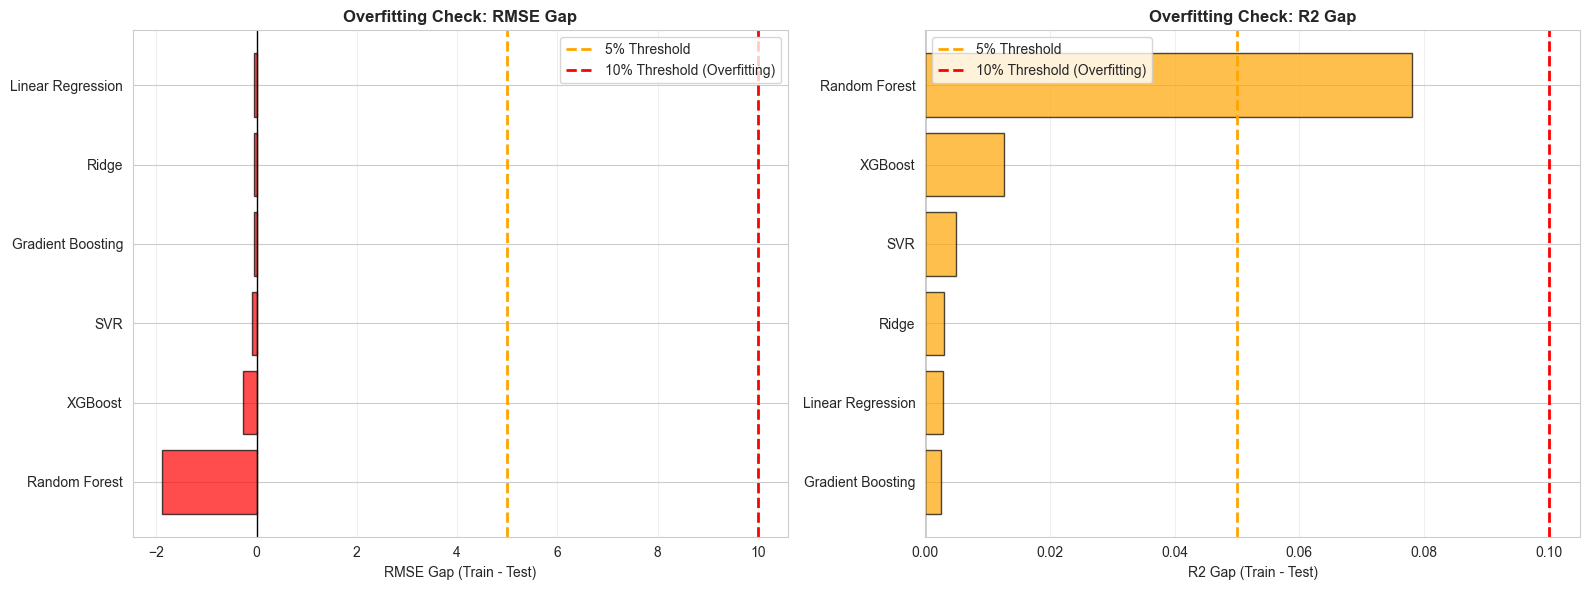


OVERFITTING ASSESSMENT

✓ Linear Regression - No significant overfitting detected
   Test R2: 0.7513
   RMSE Gap: -0.0441

✓ Ridge - No significant overfitting detected
   Test R2: 0.7513
   RMSE Gap: -0.0445

✓ Random Forest - No significant overfitting detected
   Test R2: 0.8228
   RMSE Gap: -1.8807

✓ XGBoost - No significant overfitting detected
   Test R2: 0.8213
   RMSE Gap: -0.2639

✓ Gradient Boosting - No significant overfitting detected
   Test R2: 0.8242
   RMSE Gap: -0.0479

✓ SVR - No significant overfitting detected
   Test R2: 0.7737
   RMSE Gap: -0.0859

✅ No significant overfitting detected in any model!


In [11]:
# Analyze overfitting by comparing training vs test performance
print("=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)

overfitting_analysis = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [results[m].get('Train RMSE', 0) for m in results.keys()],
    'Test RMSE': [results[m]['RMSE'] for m in results.keys()],
    'RMSE Gap': [results[m].get('RMSE Gap', 0) for m in results.keys()],
    'Train R2': [results[m].get('Train R2', 0) for m in results.keys()],
    'Test R2': [results[m]['R2'] for m in results.keys()],
    'R2 Gap': [results[m].get('R2 Gap', 0) for m in results.keys()]
})

print("\nTraining vs Test Performance Comparison:")
print(overfitting_analysis.round(4))

# Visualize overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE gap
overfitting_analysis_sorted = overfitting_analysis.sort_values('RMSE Gap', ascending=False)
axes[0].barh(range(len(overfitting_analysis_sorted)), overfitting_analysis_sorted['RMSE Gap'].values,
             color='red', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[0].axvline(5, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[0].set_yticks(range(len(overfitting_analysis_sorted)))
axes[0].set_yticklabels(overfitting_analysis_sorted['Model'])
axes[0].set_xlabel('RMSE Gap (Train - Test)', fontsize=10)
axes[0].set_title('Overfitting Check: RMSE Gap', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# R2 gap
overfitting_analysis_sorted_r2 = overfitting_analysis.sort_values('R2 Gap', ascending=False)
axes[1].barh(range(len(overfitting_analysis_sorted_r2)), overfitting_analysis_sorted_r2['R2 Gap'].values,
             color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(0.05, color='orange', linestyle='--', linewidth=2, label='5% Threshold')
axes[1].axvline(0.10, color='red', linestyle='--', linewidth=2, label='10% Threshold (Overfitting)')
axes[1].set_yticks(range(len(overfitting_analysis_sorted_r2)))
axes[1].set_yticklabels(overfitting_analysis_sorted_r2['Model'])
axes[1].set_xlabel('R2 Gap (Train - Test)', fontsize=10)
axes[1].set_title('Overfitting Check: R2 Gap', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Identify overfitted models
print("\n" + "=" * 80)
print("OVERFITTING ASSESSMENT")
print("=" * 80)

overfitted_models = []
for idx, row in overfitting_analysis.iterrows():
    model_name = row['Model']
    rmse_gap = row['RMSE Gap']
    r2_gap = row['R2 Gap']
    test_r2 = row['Test R2']
    
    is_overfitted = False
    reasons = []
    
    if rmse_gap < -10:
        is_overfitted = True
        reasons.append(f"Large RMSE gap ({rmse_gap:.2f})")
    
    if r2_gap > 0.10:
        is_overfitted = True
        reasons.append(f"Large R2 gap ({r2_gap:.2%})")
    
    if test_r2 > 0.99:
        is_overfitted = True
        reasons.append("Near-perfect test R2 (≥99%)")
    
    if is_overfitted:
        overfitted_models.append(model_name)
        print(f"\n⚠️  {model_name} - POTENTIALLY OVERFITTED")
        print(f"   Test R2: {test_r2:.4f}")
        print(f"   RMSE Gap: {rmse_gap:.4f}")
        print(f"   R2 Gap: {r2_gap:.4f}")
        print(f"   Reasons: {', '.join(reasons)}")
    else:
        print(f"\n✓ {model_name} - No significant overfitting detected")
        print(f"   Test R2: {test_r2:.4f}")
        print(f"   RMSE Gap: {rmse_gap:.4f}")

if len(overfitted_models) > 0:
    print(f"\n🚨 WARNING: {len(overfitted_models)} model(s) show signs of overfitting!")
    print(f"   Overfitted models: {', '.join(overfitted_models)}")
    print(f"\n💡 Recommendations:")
    print(f"   - Increase regularization (reduce model complexity)")
    print(f"   - Add more training data if possible")
    print(f"   - Use simpler models or reduce hyperparameters")
else:
    print(f"\n✅ No significant overfitting detected in any model!")

Model Performance Comparison (sorted by RMSE):
                     RMSE     MAE      R2  Explained Variance    MAPE
Gradient Boosting  7.4488  6.1014  0.8242              0.8243  0.0905
Random Forest      7.4790  6.1427  0.8228              0.8229  0.0912
XGBoost            7.5095  6.1406  0.8213              0.8215  0.0912
SVR                8.4523  6.9578  0.7737              0.7741  0.1060
Linear Regression  8.8604  7.2439  0.7513              0.7513  0.1112
Ridge              8.8609  7.2442  0.7513              0.7513  0.1112


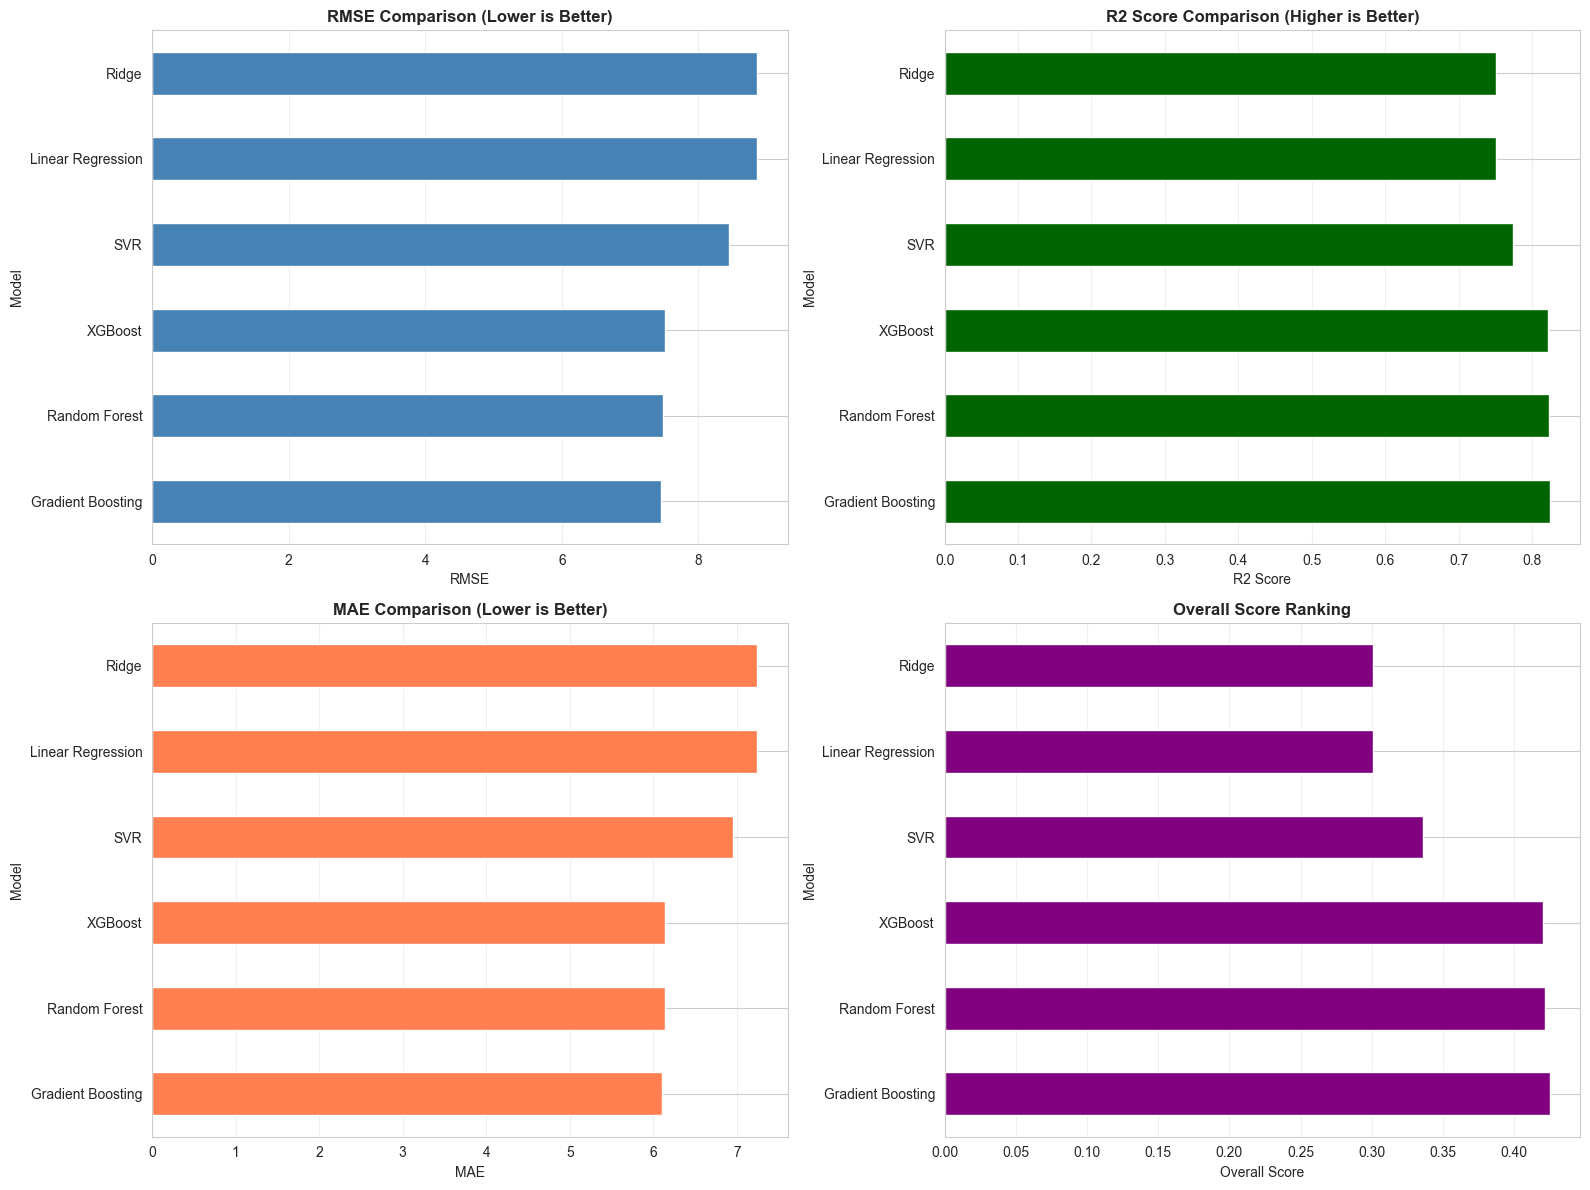


Overall Score Ranking:
                   Overall Score
Gradient Boosting         0.4250
Random Forest             0.4219
XGBoost                   0.4200
SVR                       0.3358
Linear Regression         0.3005
Ridge                     0.3005


In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
comparison_metrics = ['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE']
results_df = results_df[comparison_metrics].sort_values('RMSE', ascending=True)

print("Model Performance Comparison (sorted by RMSE):")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE comparison
results_df['RMSE'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('RMSE', fontsize=10)
axes[0, 0].set_ylabel('Model', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# R2 comparison
results_df['R2'].plot(kind='barh', ax=axes[0, 1], color='darkgreen')
axes[0, 1].set_title('R2 Score Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('R2 Score', fontsize=10)
axes[0, 1].set_ylabel('Model', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# MAE comparison
results_df['MAE'].plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('MAE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('MAE', fontsize=10)
axes[1, 0].set_ylabel('Model', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Overall ranking
results_df['Overall Score'] = (
    (1 - results_df['RMSE'] / results_df['RMSE'].max()) * 0.4 +
    results_df['R2'] * 0.4 +
    (1 - results_df['MAE'] / results_df['MAE'].max()) * 0.2
)
results_df = results_df.sort_values('Overall Score', ascending=False)

results_df['Overall Score'].plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Overall Score Ranking', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Overall Score', fontsize=10)
axes[1, 1].set_ylabel('Model', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nOverall Score Ranking:")
print(results_df[['Overall Score']].round(4))

## 9. Prediction vs Actual Visualization

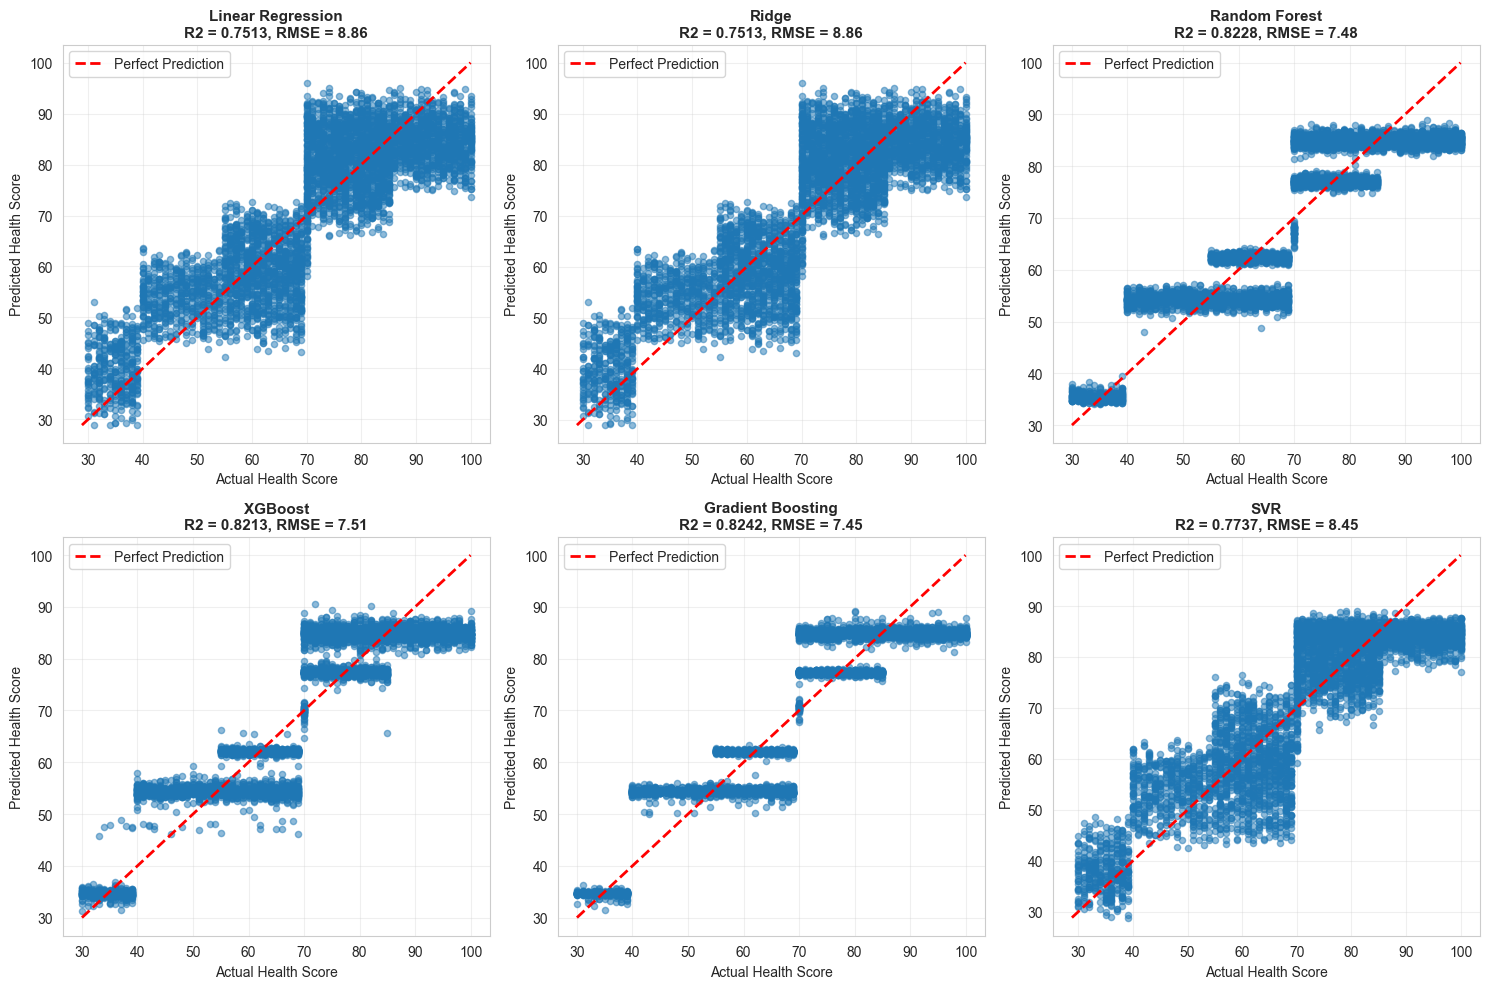

In [ ]:
# Plot predicted vs actual for all models
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Health Score', fontsize=10)
    ax.set_ylabel('Predicted Health Score', fontsize=10)
    ax.set_title(f'{name}\nR2 = {results[name]["R2"]:.4f}, RMSE = {results[name]["RMSE"]:.2f}', 
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 10. Ensemble Models

In [ ]:
# Create ensemble models using the trained base models
print("=" * 80)
print("TRAINING ENSEMBLE MODELS")
print("=" * 80)

# Use tree-based models for ensemble
base_models_for_ensemble = []
tree_model_names = ['Random Forest', 'XGBoost', 'Gradient Boosting']
for name in tree_model_names:
    if name in models:
        base_models_for_ensemble.append((name.lower().replace(' ', '_'), models[name]))

if len(base_models_for_ensemble) < 2:
    print("⚠️  Warning: Need at least 2 models for ensemble. Adding all available models...")
    for name, model in models.items():
        if name not in ['SVR']:  # Exclude SVR for ensemble
            base_models_for_ensemble.append((name.lower().replace(' ', '_'), model))

print(f"\nBase models for ensemble: {[name for name, _ in base_models_for_ensemble]}")

# Create Voting Regressor
print("\nTraining Voting Regressor...")
voting_reg = VotingRegressor(
    estimators=base_models_for_ensemble,
    n_jobs=-1
)
voting_reg.fit(X_train, y_train)

# Evaluate Voting Regressor
voting_pred = voting_reg.predict(X_test)
voting_mse = mean_squared_error(y_test, voting_pred)
voting_rmse = np.sqrt(voting_mse)
voting_mae = mean_absolute_error(y_test, voting_pred)
voting_r2 = r2_score(y_test, voting_pred)
voting_mape = mean_absolute_percentage_error(y_test, voting_pred)

results['Voting Regressor'] = {
    'MSE': voting_mse,
    'RMSE': voting_rmse,
    'MAE': voting_mae,
    'R2': voting_r2,
    'Explained Variance': explained_variance_score(y_test, voting_pred),
    'MAPE': voting_mape
}
predictions['Voting Regressor'] = voting_pred

print(f"  RMSE: {voting_rmse:.4f}")
print(f"  MAE: {voting_mae:.4f}")
print(f"  R2: {voting_r2:.4f}")
print(f"  MAPE: {voting_mape:.2%}")

# Create Stacking Regressor
print("\nTraining Stacking Regressor...")
stacking_reg = StackingRegressor(
    estimators=base_models_for_ensemble,
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_reg.fit(X_train, y_train)

# Evaluate Stacking Regressor
stacking_pred = stacking_reg.predict(X_test)
stacking_mse = mean_squared_error(y_test, stacking_pred)
stacking_rmse = np.sqrt(stacking_mse)
stacking_mae = mean_absolute_error(y_test, stacking_pred)
stacking_r2 = r2_score(y_test, stacking_pred)
stacking_mape = mean_absolute_percentage_error(y_test, stacking_pred)

results['Stacking Regressor'] = {
    'MSE': stacking_mse,
    'RMSE': stacking_rmse,
    'MAE': stacking_mae,
    'R2': stacking_r2,
    'Explained Variance': explained_variance_score(y_test, stacking_pred),
    'MAPE': stacking_mape
}
predictions['Stacking Regressor'] = stacking_pred

print(f"  RMSE: {stacking_rmse:.4f}")
print(f"  MAE: {stacking_mae:.4f}")
print(f"  R2: {stacking_r2:.4f}")
print(f"  MAPE: {stacking_mape:.2%}")

# Add ensemble models to models dictionary for saving
models['Voting Regressor'] = voting_reg
models['Stacking Regressor'] = stacking_reg

print("\n" + "=" * 80)
print("Ensemble models trained successfully!")
print("=" * 80)

TRAINING ENSEMBLE MODELS

Base models for ensemble: ['random_forest', 'xgboost', 'gradient_boosting']

Training Voting Regressor...
  RMSE: 7.4549
  MAE: 6.1079
  R2: 0.8239
  MAPE: 9.06%

Training Stacking Regressor...
  RMSE: 7.4453
  MAE: 6.1005
  R2: 0.8244
  MAPE: 9.05%

Ensemble models trained successfully!


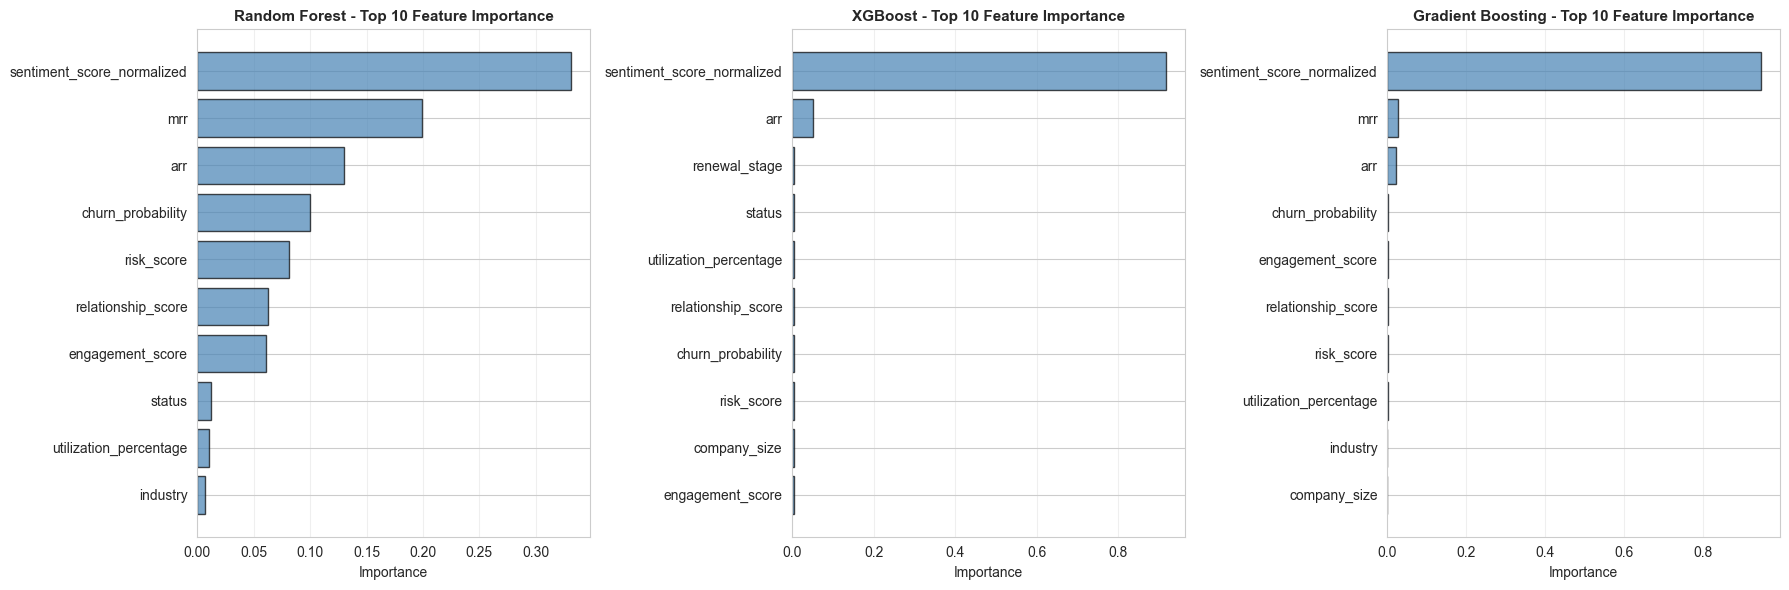

FEATURE IMPORTANCE ANALYSIS

Random Forest - Feature Importance:
------------------------------------------------------------
                   Feature  Importance
sentiment_score_normalized    0.331510
                       mrr    0.199423
                       arr    0.130144
         churn_probability    0.099778
                risk_score    0.080825
        relationship_score    0.062591
          engagement_score    0.060517
                    status    0.012441
    utilization_percentage    0.010147
                  industry    0.007093
              company_size    0.003199
             renewal_stage    0.002332
           payment_history    0.000000
      support_ticket_score    0.000000
          feature_adoption    0.000000


XGBoost - Feature Importance:
------------------------------------------------------------
                   Feature  Importance
sentiment_score_normalized    0.918352
                       arr    0.050487
             renewal_stage    0.004944
 

In [ ]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']
available_tree_models = [m for m in tree_models if m in models]

if available_tree_models:
    fig, axes = plt.subplots(1, len(available_tree_models), figsize=(6*len(available_tree_models), 6))
    if len(available_tree_models) == 1:
        axes = [axes]

    for idx, name in enumerate(available_tree_models):
        model = models[name]
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X.columns
            
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            # Plot top 10 features
            top_features = importance_df.head(10)
            axes[idx].barh(range(len(top_features)), top_features['importance'], 
                          color='steelblue', edgecolor='black', alpha=0.7)
            axes[idx].set_yticks(range(len(top_features)))
            axes[idx].set_yticklabels(top_features['feature'])
            axes[idx].set_xlabel('Importance', fontsize=10)
            axes[idx].set_title(f'{name} - Top 10 Feature Importance', 
                               fontsize=11, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, axis='x')
            axes[idx].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Display feature importance tables
    print("=" * 80)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("=" * 80)
    for name in available_tree_models:
        model = models[name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            print(f"\n{name} - Feature Importance:")
            print("-" * 60)
            print(importance_df.to_string(index=False))
            print()

In [16]:
# Create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Generate timestamp for file naming
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("=" * 80)
print("SAVING MODELS")
print("=" * 80)

# Save all individual models
saved_models = {}
for name, model in models.items():
    # Create safe filename
    safe_name = name.lower().replace(' ', '_')
    model_filename = models_dir / f"health_score_model_{safe_name}_{timestamp}.pkl"
    
    joblib.dump(model, model_filename)
    saved_models[name] = str(model_filename)
    print(f"✓ Saved {name}: {model_filename.name}")

# Save preprocessing objects
preprocessing_filename = models_dir / f"health_score_preprocessing_{timestamp}.pkl"
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': list(X.columns),
    'numerical_features': available_numerical,
    'categorical_features': available_categorical
}
joblib.dump(preprocessing_data, preprocessing_filename)
print(f"✓ Saved preprocessing objects: {preprocessing_filename.name}")

# Determine best model based on Overall Score
results_df_full = pd.DataFrame(results).T
if 'Overall Score' not in results_df_full.columns:
    results_df_full['Overall Score'] = (
        (1 - results_df_full['RMSE'] / results_df_full['RMSE'].max()) * 0.4 +
        results_df_full['R2'] * 0.4 +
        (1 - results_df_full['MAE'] / results_df_full['MAE'].max()) * 0.2
    )

best_model_name = results_df_full['Overall Score'].idxmax()
best_model = models[best_model_name]

# Save best model separately
best_model_filename = models_dir / f"health_score_model_best_{timestamp}.pkl"
joblib.dump(best_model, best_model_filename)
print(f"✓ Saved BEST MODEL ({best_model_name}): {best_model_filename.name}")

# Save model results
results_filename = models_dir / f"health_score_model_results_{timestamp}.csv"
results_df_full[['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE', 'Overall Score']].to_csv(results_filename)
print(f"✓ Saved model results: {results_filename.name}")

# Save results as pickle for easy loading
results_pickle_filename = models_dir / f"health_score_model_results_{timestamp}.pkl"
with open(results_pickle_filename, 'wb') as f:
    import pickle
    pickle.dump({
        'results': results,
        'predictions': predictions,
        'best_model_name': best_model_name,
        'cv_results': cv_results if 'cv_results' in locals() else {},
        'timestamp': timestamp
    }, f)
print(f"✓ Saved detailed results: {results_pickle_filename.name}")

print("\n" + "=" * 80)
print("MODEL SAVING SUMMARY")
print("=" * 80)
print(f"Total models saved: {len(saved_models)}")
print(f"Best model: {best_model_name} (Overall Score: {results_df_full.loc[best_model_name, 'Overall Score']:.4f})")
print(f"Models directory: {models_dir.absolute()}")
print(f"Timestamp: {timestamp}")
print("\n" + "=" * 80)
print("Model Training and Saving Complete! 🎉")
print("=" * 80)

SAVING MODELS
✓ Saved Linear Regression: health_score_model_linear_regression_20260214_224009.pkl
✓ Saved Ridge: health_score_model_ridge_20260214_224009.pkl
✓ Saved Random Forest: health_score_model_random_forest_20260214_224009.pkl
✓ Saved XGBoost: health_score_model_xgboost_20260214_224009.pkl
✓ Saved Gradient Boosting: health_score_model_gradient_boosting_20260214_224009.pkl
✓ Saved SVR: health_score_model_svr_20260214_224009.pkl
✓ Saved Voting Regressor: health_score_model_voting_regressor_20260214_224009.pkl
✓ Saved Stacking Regressor: health_score_model_stacking_regressor_20260214_224009.pkl
✓ Saved preprocessing objects: health_score_preprocessing_20260214_224009.pkl
✓ Saved BEST MODEL (Stacking Regressor): health_score_model_best_20260214_224009.pkl
✓ Saved model results: health_score_model_results_20260214_224009.csv
✓ Saved detailed results: health_score_model_results_20260214_224009.pkl

MODEL SAVING SUMMARY
Total models saved: 8
Best model: Stacking Regressor (Overall Scor

## 13. Final Summary

In [ ]:
# Final summary of all models
print("=" * 80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 80)

final_results_df = pd.DataFrame(results).T
final_results_df = final_results_df[['RMSE', 'MAE', 'R2', 'Explained Variance', 'MAPE']].sort_values('RMSE', ascending=True)

print("\nAll Models Performance (sorted by RMSE):")
print(final_results_df.round(4))

print(f"\n{'='*80}")
print("BEST MODEL SELECTION")
print(f"{'='*80}")
print(f"Best Model: {best_model_name}")
print(f"  RMSE: {final_results_df.loc[best_model_name, 'RMSE']:.4f}")
print(f"  MAE: {final_results_df.loc[best_model_name, 'MAE']:.4f}")
print(f"  R2: {final_results_df.loc[best_model_name, 'R2']:.4f}")
print(f"  Explained Variance: {final_results_df.loc[best_model_name, 'Explained Variance']:.4f}")
print(f"  MAPE: {final_results_df.loc[best_model_name, 'MAPE']:.2%}")

print(f"\n{'='*80}")
print("MODEL TRAINING PIPELINE COMPLETE!")
print(f"{'='*80}")
print(f"✓ {len(models)} models trained")
print(f"✓ Hyperparameter tuning: {'Enabled' if ENABLE_TUNING else 'Disabled'}")
print(f"✓ Ensemble models: Voting Regressor, Stacking Regressor")
print(f"✓ All models saved to: {models_dir.absolute()}")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Ready for production use!")
print(f"{'='*80}")

FINAL MODEL PERFORMANCE SUMMARY

All Models Performance (sorted by RMSE):
                      RMSE     MAE      R2  Explained Variance    MAPE
Stacking Regressor  7.4453  6.1005  0.8244              0.8245  0.0905
Gradient Boosting   7.4488  6.1014  0.8242              0.8243  0.0905
Voting Regressor    7.4549  6.1079  0.8239              0.8240  0.0906
Random Forest       7.4790  6.1427  0.8228              0.8229  0.0912
XGBoost             7.5095  6.1406  0.8213              0.8215  0.0912
SVR                 8.4523  6.9578  0.7737              0.7741  0.1060
Linear Regression   8.8604  7.2439  0.7513              0.7513  0.1112
Ridge               8.8609  7.2442  0.7513              0.7513  0.1112

BEST MODEL SELECTION
Best Model: Stacking Regressor
  RMSE: 7.4453
  MAE: 6.1005
  R2: 0.8244
  Explained Variance: 0.8245
  MAPE: 9.05%

MODEL TRAINING PIPELINE COMPLETE!
✓ 8 models trained
✓ Hyperparameter tuning: Enabled
✓ Ensemble models: Voting Regressor, Stacking Regressor
✓ All 